In [28]:
import re
import time
import abc
import warnings
import json
import os
import functools
import subprocess
from pathlib import Path

import torch
import torchgeo
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Optional, Tuple, cast, Union, Iterator
from rtree.index import Index, Property
import pandas as pd
import geopandas as gpd
import rasterio
import timm

import torch.nn.functional as F
import torchvision.transforms as Tr
from torch.optim import Adam
from transformers import AutoVideoProcessor, AutoModel
from kornia.augmentation import AugmentationSequential
from torch.utils.data import DataLoader, Sampler
from torchgeo.datasets import RasterDataset, stack_samples, BoundingBox, GeoDataset
from torchgeo.samplers import GridGeoSampler, RandomGeoSampler
from torchgeo.samplers.constants import Units
from torchgeo.samplers.utils import _to_tuple, get_random_bounding_box, tile_to_chips
import torch.optim.lr_scheduler as lr_scheduler

from utils.train_utils import *
os.chdir("D:/githubs/vjepa2")
#os.chdir(os.path.join(os.getcwd(), ".."))
import src.datasets.utils.video.transforms as video_transforms
import src.datasets.utils.video.volume_transforms as volume_transforms
from src.models.attentive_pooler import AttentiveClassifier
from src.models.vision_transformer import vit_giant_xformers_rope


from src.Prithvi.Prithvi_run_inference import MaskedAutoencoderViT
from DOFA.models_dwv import vit_base_patch16

np.random.seed(42)

In [27]:
IMAGENET_DEFAULT_MEAN = (0.485*255, 0.456*255, 0.406*255)
IMAGENET_DEFAULT_STD = (0.229*255, 0.224*255, 0.225*255)

In [ ]:
Nb_dates = 6
extensions = ('.tif', '.tiff', '.TIF', '.TIFF')
img_dir = "D:/Phenologie/DL_Phenophases/data/Paracou/img"
img_files = sorted([file for file in os.listdir(img_dir) if file.endswith(extensions) and "mask" not in file])
print(img_files)
dates_data_df = pd.DataFrame({'img':img_files})

start = int(Nb_dates/2)
end = len(dates_data_df) - int((Nb_dates-1)/2)

In [ ]:
"""
# HuggingFace model repo name
hf_model_name = (
    "facebook/vjepa2-vitg-fpc64-384"  # Replace with your favored model, e.g. facebook/vjepa2-vitg-fpc64-384
)
# Path to local PyTorch weights
pt_model_path = "YOUR_MODEL_PATH"

# Initialize the HuggingFace model, load pretrained weights
model_hf = AutoModel.from_pretrained(hf_model_name)
model_hf.cuda().eval()
"""

def load_pretrained_vjepa_pt_weights(model, pretrained_weights):
    # Load weights of the VJEPA2 encoder
    # The PyTorch state_dict is already preprocessed to have the right key names
    pretrained_dict = torch.load(pretrained_weights, weights_only=True, map_location="cpu")["encoder"]
    pretrained_dict = {k.replace("module.", ""): v for k, v in pretrained_dict.items()}
    pretrained_dict = {k.replace("backbone.", ""): v for k, v in pretrained_dict.items()}
    msg = model.load_state_dict(pretrained_dict, strict=False)
    print("Pretrained weights found at {} and loaded with msg: {}".format(pretrained_weights, msg))


def load_pretrained_vjepa_classifier_weights(model, pretrained_weights):
    # Load weights of the VJEPA2 classifier
    # The PyTorch state_dict is already preprocessed to have the right key names
    pretrained_dict = torch.load(pretrained_weights, weights_only=True, map_location="cpu")["classifiers"][0]
    pretrained_dict = {k.replace("module.", ""): v for k, v in pretrained_dict.items()}
    msg = model.load_state_dict(pretrained_dict, strict=False)
    print("Pretrained weights found at {} and loaded with msg: {}".format(pretrained_weights, msg))


def build_pt_video_transform(img_size):
    short_side_size = int(256.0 / 224 * img_size)
    # Eval transform has no random cropping nor flip
    eval_transform = video_transforms.Compose(
        [
            video_transforms.Resize(short_side_size, interpolation="bilinear"),
            video_transforms.CenterCrop(size=(img_size, img_size)),
            volume_transforms.ClipToTensor(),
            video_transforms.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD),
        ]
    )
    return eval_transform


def forward_vjepa(imgs, model):
    # Run a sample inference with VJEPA
    print(imgs.shape)
    with torch.inference_mode():
        # Read and pre-process the image
        # video = get_video()  # T x H x W x C
        # video = torch.from_numpy(video).permute(0, 3, 1, 2)  # T x C x H x W
        # x = transform(video).cuda().unsqueeze(0)
        # Extract the patch-wise features from the last layer
        #imgs = torch.einsum('btchw->bcthw', imgs)  # B x T x C x H x W -> B x C x T x H x W
        out_patch_features = model(imgs)
        #out_patch_features_hf = model_hf.get_vision_features(x_hf)

    return out_patch_features


def get_vjepa_classification_results(classifier, out_patch_features):
    PHENO_CLASSES = json.load(open("pheno_classes.json", "r"))

    with torch.inference_mode():
        out_classifier = classifier(out_patch_features)
    preds = out_classifier.argmax(1)
    for pred in preds.detach().cpu().numpy():
        print(PHENO_CLASSES[str(pred)])

    return

#### Prithvi multiple dates

In [21]:
def forward_vjepa(imgs, model):
    print(imgs.shape)
    with torch.inference_mode():
        imgs = torch.einsum('btchw->bcthw', imgs)  # B x T x C x H x W -> B x C x T x H x W
        out_patch_features = model(imgs)
        #out_patch_features_hf = model_hf.get_vision_features(x_hf)

    return out_patch_features

In [ ]:
targSize = 224
tile_size = 112
sep_dates = True

decoder_depth=8
decoder_embed_dim=512
decoder_num_heads=16
depth=12
embed_dim=768
in_chans=3  #len(band_indices) if band_indices is not None else 3
num_frames=Nb_dates
num_heads=12
patch_size=16
tubelet_size=2

encoder = MaskedAutoencoderViT(
            img_size=targSize,
            patch_size=patch_size,
            num_frames=num_frames,
            tubelet_size=tubelet_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            decoder_embed_dim=decoder_embed_dim,
            decoder_depth=decoder_depth,
            decoder_num_heads=decoder_num_heads,
            mlp_ratio=4.0,
            norm_layer=functools.partial(torch.nn.LayerNorm, eps=1e-6),
            norm_pix_loss=False,
        )
state_dict = torch.load("D:/githubs/Prithvi_100M/Prithvi_100M.pt")
del state_dict["pos_embed"]
del state_dict["decoder_pos_embed"]
del state_dict['patch_embed.proj.weight']
del state_dict['patch_embed.proj.bias']
del state_dict["decoder_pred.weight"]
del state_dict["decoder_pred.bias"]
encoder.load_state_dict(state_dict, strict = False)
encoder.cuda()

classifier = (
    AttentiveClassifier(embed_dim=encoder.decoder_pred.out_features, num_heads=16, depth=4, num_classes=4).cuda().eval()
)

In [ ]:
transforms=DictTransform(AugmentationSequential(T.Resize((targSize, targSize)), T.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD), data_keys=["image"]))

for k in range(start, start+1): #end
    filepaths = [os.path.join(img_dir, dates_data_df['img'][i]) for i in range(k-int(Nb_dates/2), k+int((Nb_dates+1)/2))]
    print("filepaths : ", filepaths)
    inf_dataset = MultiDateRGBDataset(filepaths, transforms=transforms, sep_dates=False)

sampler = RandomGeoSampler(inf_dataset, size=tile_size, length=10)
dataloader = DataLoader(inf_dataset, batch_size=1, sampler=sampler, collate_fn=stack_samples, shuffle=False)
for batch in dataloader:
    img = batch['image'].cuda()
    feat = forward_vjepa(img, encoder)       #out = B x num_patches x embed_dim = B x 14*14*nb_dates/tubelet_size x 1536 = B x 588 x 1536
    #print(feat[1].shape)
    get_vjepa_classification_results(classifier, feat[1])
    

#### Dinov2 Single date

In [13]:
def forward_vjepa(imgs, model):
    with torch.inference_mode():
        out_patch_features = model.forward_features(imgs)
        #out_patch_features_hf = model_hf.get_vision_features(x_hf)

    return out_patch_features

In [14]:
img_dir = "Z:/shared/PhenOBS_Africa/Mbalmayo/Mosa_rect_Oct2025"
targSize = 518
tile_size = 74

transforms = DictTransform(AugmentationSequential(T.Resize((targSize, targSize)), T.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD), data_keys=["image"]))

encoder = timm.create_model('vit_base_patch14_dinov2', pretrained=True)
encoder.cuda()

classifier = (
    AttentiveClassifier(embed_dim=encoder.num_features, num_heads=16, depth=4, num_classes=4).cuda().eval()
)
classifier.cuda()

AttentiveClassifier(
  (pooler): AttentivePooler(
    (cross_attention_block): CrossAttentionBlock(
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (xattn): CrossAttention(
        (q): Linear(in_features=768, out_features=768, bias=True)
        (kv): Linear(in_features=768, out_features=1536, bias=True)
      )
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
    (blocks): ModuleList(
      (0-2): 3 x Block(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, b

In [ ]:
files_list = [file for file in os.listdir(img_dir) if file.endswith(extensions)]
print(files_list)
for f in files_list[:1]:
    print(f)
    inf_dataset = RobustGeoDataset(RasterDataset(paths=[os.path.join(img_dir, f)], transforms=transforms))
    sampler = RandomGeoSampler(inf_dataset, size=tile_size, length=10)
    dataloader = DataLoader(inf_dataset, batch_size=1, sampler=sampler, collate_fn=stack_samples, shuffle=False)
    for batch in dataloader:
        img = batch['image'].cuda()
        feat = forward_vjepa(img, encoder)       #out = B x num_patches x embed_dim = B x 14*14 x 768
        print(feat.shape)
        get_vjepa_classification_results(classifier, feat[:, 1:])

#### Embeddings pré-calculation

In [3]:
shp_path = "D:/Phenologie/DL_Phenophases/data/Mbalmayo/Mbalmayo_crowns_2024_04_05_32632.gpkg"
crowns_shp = gpd.read_file(shp_path)
for i in range(len(crowns_shp)):
    if crowns_shp['geometry'][i].geom_type == 'MultiPolygon':
        crowns_shp['geometry'][i] = crowns_shp['geometry'][i].geoms[0]

list_rois = [polygon_to_bbox(poly) for poly in crowns_shp['geometry']]

extensions = ('.tif', '.tiff', '.TIF', '.TIFF')
img_dir = "Z:/shared/PhenOBS_Africa/Mbalmayo/Mosa_rect_Oct2025"
Mbal24_dates = [f for f in os.listdir(img_dir) if f.endswith(extensions)][34:58]

##### DOFA

In [4]:
targSize = 224
tile_size = 112
wavelengths = [0.665, 0.56, 0.49]

transforms = DictTransform(AugmentationSequential(Tr.Resize((targSize, targSize)), Tr.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD), data_keys=["image"]))

encoder = vit_base_patch16(global_pool=False, img_size=224)
state_dict = torch.load("Z:/users/HadrienTulet/DL_pheno/models/DOFA/checkpoints/DOFA_ViT_base_e100.pth")
encoder.load_state_dict(state_dict, strict=False)
encoder.head = nn.Identity()
encoder.cuda()

OFAViT(
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (patch_embed): Dynamic_MLP_OFA(
    (weight_generator): TransformerWeightGenerator(
      (transformer_encoder): TransformerEncoder(
        (layers): ModuleList(
          (0): TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
            )
            (linear1): Linear(in_features=128, out_features=2048, bias=True)
            (dropout): Dropout(p=False, inplace=False)
            (linear2): Linear(in_features=2048, out_features=128, bias=True)
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (dropout1): Dropout(p=False, inplace=False)
            (dropout2): Dropout(p=False, inplace=False)
          )
        )
      )
      (fc_weight): Linear(in_features=128, out_features=196

##### Dinov2

In [74]:
targSize = 518
tile_size = 74

transforms = DictTransform(AugmentationSequential(T.Resize((targSize, targSize)), T.Normalize(mean=IMAGENET_DEFAULT_MEAN, std=IMAGENET_DEFAULT_STD), data_keys=["image"]))

encoder = timm.create_model('vit_base_patch14_dinov2', pretrained=True)
encoder.cuda()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=Fal

##### Processing

In [ ]:
out_dir = "Z:/users/HadrienTulet/DL_pheno/vjepa/DOFA_Mbal24_patchtokens"
out_dir_cls = "Z:/users/HadrienTulet/DL_pheno/vjepa/DOFA_Mbal24_clstokens"

print(Mbal24_dates)
for file in Mbal24_dates:
    print(file)
    inf_dataset = RobustGeoDataset(RasterDataset(paths=[os.path.join(img_dir, file)], transforms=transforms))
    sampler = MultipleGridGeoSampler(inf_dataset, size=tile_size, stride=tile_size, roi_bounds=list_rois)
    dataloader = DataLoader(inf_dataset, batch_size=1, sampler=sampler, collate_fn=skip_none_collate, shuffle=False)
    date = file.split("_")[0]
    N = len(dataloader)
    blank = np.zeros((N, int((targSize/encoder.patch_embed.patch_size[0])**2), 768), dtype=np.float16)          #encoder.num_features
    blank_cls = np.zeros((N, 768), dtype=np.float16)
    print(blank.shape)
    for i, batch in enumerate(dataloader):
        if batch is None:
            continue
        else:
            print(f"{i/N:.2%}", end="\r")
            bboxes = batch['bbox']
            img = batch['image'].cuda()
            with torch.inference_mode():
                feat = encoder.forward_features(img, wave_list = wavelengths)                #out = B x num_patches x embed_dim = B x 14*14 x 768
                feat = feat.detach().cpu().numpy().astype(np.float16).squeeze(0)
                blank[i] = feat[1:]
                blank_cls[i] = feat[1]
    np.save(os.path.join(out_dir, f"{date}_features.npy"), blank)
    np.save(os.path.join(out_dir_cls, f"{date}_clstokens.npy"), blank_cls)

#### Reshape features spatially

In [3]:
feat_dir = "Z:/users/HadrienTulet/DL_pheno/vjepa/DOFA_Mbal24_patchtokens"
output_dir = Path("D:/Phenologie/DL_Phenophases/vjepa/tokens_DOFA_Mbal24_reshape")
k = 23

input_dir  = Path(feat_dir)
output_dir.mkdir(parents=True, exist_ok=True)

arrays = [np.load(os.path.join(input_dir, f), mmap_mode='r') for f in os.listdir(input_dir)]

N = arrays[0].shape[0]
assert all(a.shape[0] == N for a in arrays), "All dates must have the same N"
assert N % k == 0, f"N={N} is not evenly divisible by k={k}"

chunk_size = N // k
print(f"N={N}, k={k}, chunk_size={chunk_size}")

for i in range(k):
    out_path = os.path.join(output_dir, f"chunk_{i}_features.npy")
    print(out_path)
    if not os.path.exists(out_path):
        start, end = i * chunk_size, (i + 1) * chunk_size

        chunk = np.stack([a[start:end] for a in arrays], axis=0)

        np.save(out_path, chunk)
        print(f"  Saved")

print("Done.")

N=23483, k=23, chunk_size=1021
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_0_features.npy
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_1_features.npy
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_2_features.npy
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_3_features.npy
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_4_features.npy
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_5_features.npy
  Saved
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_6_features.npy
  Saved
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_7_features.npy
  Saved
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_8_features.npy
  Saved
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_9_features.npy
  Saved
D:\Phenologie\DL_Phenophases\vjepa\tokens_DOFA_Mbal24_reshape\chunk_10_features.npy
  Saved
D:\Phen

#### Auto-supervised training

In [15]:
loss_fn = torch.nn.L1Loss()

In [16]:
class TemporalAggregator(nn.Module):                #Patches are treated indepentently
    def __init__(self, embed_dim, num_heads=8, num_layers=2, cls = False):
        super().__init__()
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.query = nn.Parameter(torch.randn(1, 1, embed_dim))  # learned aggregation token
        self.cls = cls

    def forward(self, x):  # x: (B, T, N, D)
        if not self.cls :
            B, T, N, D = x.shape
            # Process each spatial token's temporal sequence independently
            x = x.permute(0, 2, 1, 3).reshape(B * N, T, D)  # (B*N, T, D)
            # Prepend learned query token
            q = self.query.expand(B * N, -1, -1)             # (B*N, 1, D)
        else:
            B, T, D = x.shape
            N = 1
            q = self.query.expand(B, -1, -1)             # (B, 1, D)
        
        x = torch.cat([q, x], dim=1)                     # (B / B*N, T+1, D)
        
        x = self.transformer(x)                          # (B / B*N, T+1, D)
        x = x[:, 0]                                      # take query token → (B / B*N, D)
        
        return x.reshape(B, D) if self.cls else x.reshape(B, N, D)                        # (B, N, D) / (B, D)

In [19]:
"""
classifier = (
    AttentiveClassifier(embed_dim=768, num_heads=16, depth=4).cuda().eval()
)
classifier.linear = nn.Identity()
classifier = classifier.half()
classifier = classifier.cuda()
"""
classifier = TemporalAggregator(embed_dim = 768, num_heads=16, num_layers=4, cls=True).cuda()#.eval()          # Treats each patch idependently
classifier

TemporalAggregator(
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=768, bias=True)
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
)

In [ ]:
import abc
import os
from tqdm import tqdm
 
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import List, Optional, Tuple, cast, Union, Iterator
from rtree.index import Index, Property
import rasterio

from torch.utils.data import DataLoader, Sampler, Dataset
from torch.optim import Adam
from torchgeo.datasets import RasterDataset, stack_samples, BoundingBox, GeoDataset
from torchgeo.samplers.constants import Units
from torchgeo.samplers.utils import _to_tuple, get_random_bounding_box, tile_to_chips

os.chdir("D:/githubs/vjepa2")


class TileWindowDataset(Dataset):
    """
    Loads one .npy file of shape (T_total, N, N_patches, embed_dim) and
    exposes every (tile, time_window) pair as an individual sample.

    Each sample is:
        vec     — (T, N_patches, embed_dim)  input window
        target  — (N_patches, embed_dim)     frame immediately after the window
        tile_idx — int, for debugging / analysis
    """

    def __init__(self, filepath: str, T: Union[int, tuple], transforms = None, p: float=0.2):
        # feat_data: (T_total, N, N_patches, embed_dim)
        
        self.data = torch.from_numpy(
            np.load(filepath, mmap_mode='r')
        )
        print(f"{os.path.basename(filepath)} : {self.data.shape}")
        #self.data = self.data[:, :100]
        self.T       = T
        self.T_total = self.data.shape[0]
        self.N       = self.data.shape[1]
        self.T_max = T[-1] if isinstance(T, tuple) else T

        # build flat index: list of (tile_idx, t) pairs
        selected_inds = []
        
        for t in range(self.T_total - self.T_max):
            if np.random.random()<p:
                selected_inds.append(t)
        if not selected_inds:
            selected_inds.append(np.random.randint(self.T_total - self.T_max))
        print(selected_inds)
        self.indices = [
            (n, t)
            for n in range(self.N)
            for t in selected_inds
        ]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        n, t = self.indices[idx]
        vec    = self.data[t : t + self.T_max, n]       # (T, N_patches, embed_dim)
        target = self.data[t + self.T_max, n]           # (N_patches, embed_dim)
        return vec, target

def run_epoch(classifier, loader, optimizer, loss_fn, train: bool, scheduler = None):

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    classifier.train() if train else classifier.eval()
    total_loss, n_steps = 0.0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for vec, target in tqdm(loader):
            # vec:    (B, T, N_patches, embed_dim)
            # target: (B, N_patches, embed_dim)
            vec    = vec.to(DEVICE)
            target = target.to(DEVICE).detach()     # stop-gradient on target
            predicted = classifier(vec)             # (B, N_patches, embed_dim)
            loss      = loss_fn(predicted, target)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                if scheduler:
                    scheduler.step()

            total_loss += loss.item()
            n_steps    += 1

    return total_loss / n_steps

def train_loop(classifier: nn.Module, feat_dir: str, out_path: str, T: Union[int, tuple], loss_fn: nn.Module, batch_size: int, N_epochs: int, lr: float, n_workers: int = 1):

    def collate_random_T(batch):
        vecs, targets = zip(*batch)
        if isinstance(T, tuple):
            rd_T = np.random.randint(T[0], T[1])
        else:
            rd_T = T
        vecs   = torch.stack([v[-rd_T:] for v in vecs])   # (B, T, N_patches, D)
        targets = torch.stack(list(targets))            # (B, N_patches, D)
        return vecs, targets

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    features_files = sorted(os.listdir(feat_dir))
    sep = int(np.floor(3*len(features_files)/4))
    print(sep)
    train_files = features_files[:sep]#[:1]
    val_files = features_files[sep:]#[:1]
    print("Train files : \n", train_files, "\nVal files : \n", val_files)
    
    optimizer = Adam(classifier.parameters(), lr=lr)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
    classifier.to(DEVICE)
    train_losses, val_losses = [], []
    for epoch in range(N_epochs):
        print(f"\nEpoch {epoch+1}/{N_epochs}")

        # Training
        train_loss = 0.0
        print("Train : ")
        for f in train_files:
            dataset = TileWindowDataset(os.path.join(feat_dir, f), T=T)
            loader  = DataLoader(
                dataset,
                batch_size=batch_size,
                shuffle=True,
                collate_fn = collate_random_T,
            )
            train_loss += run_epoch(classifier, loader, optimizer, loss_fn, scheduler=scheduler, train=True)
        train_loss /= max(len(train_files), 1)
        train_losses.append(train_loss)
        # Val
        val_loss = 0.0
        print("\nValidation : ")
        for f in val_files:
            dataset = TileWindowDataset(os.path.join(feat_dir, f), T=T)
            loader  = DataLoader(
                dataset,
                batch_size=batch_size,
                shuffle=False,
                collate_fn = collate_random_T,
            )
            val_loss += run_epoch(classifier, loader, optimizer, loss_fn, scheduler=scheduler, train=False)
        val_loss /= max(len(val_files), 1)

        print(f"  train loss: {train_loss:.6f}  |  val loss: {val_loss:.6f}")

        val_losses.append(val_loss)
        if val_loss == np.min(val_losses):
            torch.save(classifier.state_dict, os.path.join(out_path, "trained_classif_vjepa_Mbal24_cls.pth"))

    X = np.array([i+1 for i in range(N_epochs)])
    plt.plot(X, train_losses)
    plt.plot(X, val_losses)
    plt.show()

    return train_losses, val_losses

17
Train files : 
 ['chunk_0_features.npy', 'chunk_10_features.npy', 'chunk_11_features.npy', 'chunk_12_features.npy', 'chunk_13_features.npy', 'chunk_14_features.npy', 'chunk_15_features.npy', 'chunk_16_features.npy', 'chunk_17_features.npy', 'chunk_18_features.npy', 'chunk_19_features.npy', 'chunk_1_features.npy', 'chunk_20_features.npy', 'chunk_21_features.npy', 'chunk_22_features.npy', 'chunk_2_features.npy', 'chunk_3_features.npy'] 
Val files : 
 ['chunk_4_features.npy', 'chunk_5_features.npy', 'chunk_6_features.npy', 'chunk_7_features.npy', 'chunk_8_features.npy', 'chunk_9_features.npy']

Epoch 1/10
Train : 
chunk_0_features.npy : torch.Size([24, 1021, 768])
[3]


100%|██████████| 32/32 [00:05<00:00,  5.80it/s]


chunk_10_features.npy : torch.Size([24, 1021, 768])
[2]


100%|██████████| 32/32 [00:05<00:00,  5.95it/s]


chunk_11_features.npy : torch.Size([24, 1021, 768])
[1]


...

chunk_8_features.npy : torch.Size([24, 1021, 768])
[0]


100%|██████████| 32/32 [00:03<00:00,  8.61it/s]


chunk_9_features.npy : torch.Size([24, 1021, 768])
[1]


100%|██████████| 32/32 [00:03<00:00,  9.02it/s]


  train loss: 0.593241  |  val loss: 0.610551


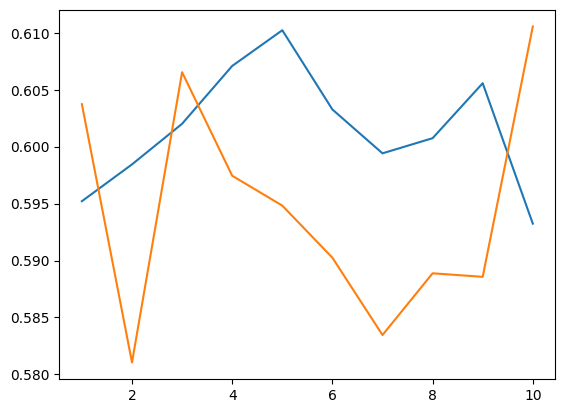

([0.5952088913022011,
  0.5984416138928603,
  0.6020073146175813,
  0.6070849031903872,
  0.6102208134480843,
  0.60326322706818,
  0.599412417915814,
  0.6007420013786531,
  0.6055680888650172,
  0.5932409330545103],
 [0.6037275314641496,
  0.5810490290944775,
  0.6065334871721765,
  0.5974451896424094,
  0.5948212080531651,
  0.5902479412034154,
  0.5834592375904322,
  0.5888786829697589,
  0.5885691537211338,
  0.6105505541587869])

In [31]:
train_loop(classifier, feat_dir="D:/Phenologie/DL_Phenophases/vjepa/clstokens_DOFA_Mbal24_reshape", out_path = "Z:/users/HadrienTulet/DL_pheno/vjepa/outputs", T=(5, 20), batch_size=32, loss_fn = loss_fn, lr=1e-4, N_epochs = 10)

##### Tests

In [7]:
train_data = np.load("Z:/users/HadrienTulet/DL_pheno/vjepa/dinov2_Mbal25_patchtokens_reshape/chunk_0_features.npy", mmap_mode='r')
train_data = torch.from_numpy(np.transpose(train_data, (1, 0, 2, 3)))
train_data.shape

val_data = np.load("Z:/users/HadrienTulet/DL_pheno/vjepa/dinov2_Mbal25_patchtokens_reshape/chunk_1_features.npy", mmap_mode='r')
val_data = torch.from_numpy(np.transpose(val_data, (1, 0, 2, 3)))
val_data.shape

C:\Users\tulet\AppData\Local\Temp\ipykernel_25616\3891279780.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  train_data = torch.from_numpy(np.transpose(train_data, (1, 0, 2, 3)))


torch.Size([1021, 24, 196, 768])

In [ ]:
T = 20

feat_dir = "Z:/users/HadrienTulet/DL_pheno/vjepa/dinov2_Mbal25_patchtokens_reshape"
features_files = os.listdir(feat_dir)
sep = int(np.ceil(len(features_files)/4))
train_files = features_files[:sep]
val_files = features_files[sep:]

for f in train_files:
    print(f)
    feat_data = np.load(os.path.join(feat_dir, f))
    feat_data = torch.from_numpy(np.transpose(feat_data, (1, 0, 2, 3)))
    for t in range(feat_data.shape[1]-T):
        vec = feat_data[:, t:t+T]
        tgt_vec = feat_data[:, t+T]
        vec = vec.cuda()
        tgt_vec = tgt_vec.cuda()
        res = classifier(vec)
        loss = loss_fn(res, tgt_vec)
        print(res.shape)

for f in val_files:
    print(f)
    feat_data = np.load(os.path.join(feat_dir, f))
    feat_data = torch.from_numpy(np.transpose(feat_data, (1, 0, 2, 3)))
    for t in range(feat_data.shape[1]-T):
        vec = feat_data[:, t:t+T]
        tgt_vec = feat_data[:, t+T]
        vec = vec.cuda()
        tgt_vec = tgt_vec.cuda()
        res = classifier(vec)
        loss = loss_fn(res, tgt_vec)
        print(res.shape)

In [11]:
vec = train_data[0:2, :20]
tgt_vec = train_data[0:2, 20]
vec = vec.to("cuda")
tgt_vec = tgt_vec.to("cuda")

In [12]:
vec.shape

torch.Size([2, 20, 196, 768])

In [13]:
res = classifier(vec)
res.shape

torch.Size([2, 196, 768])